In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import bz2
import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../outputs/customer_rfm.csv')

with open('../models/best_model.pickle','rb') as f:
    cltv_model=pickle.load(f)
with open('../models/churn_features.pickle','rb') as f:
    CLTV_FEATURES=pickle.load(f)
    
with open('../models/churn_model.pickle','rb') as f:
    churn_model=pickle.load(f)
with open('../models/churn_features.pickle','rb') as f:
    CHURN_FEATURES=pickle.load(f)
    
print("CLTV model:",type(cltv_model).__name__)
print("CLTV features:",type(CLTV_FEATURES).__name__)
print("Churn model:",type(churn_model).__name__)
print("Churn features:",type(CHURN_FEATURES).__name__)

CLTV model: RandomForestRegressor
CLTV features: list
Churn model: XGBClassifier
Churn features: list


In [7]:
X_cltv=df[CLTV_FEATURES].fillna(0)
X_churn=df[CHURN_FEATURES].fillna(0)

print("X_cltv shape:",X_cltv.shape)
print("X_churn shape:",X_churn.shape)

X_cltv shape: (4228, 6)
X_churn shape: (4228, 6)


In [11]:
SAMPLE_SIZE = min(1000, len(X_cltv))
X_cltv_sample = X_cltv.sample(n=SAMPLE_SIZE, random_state=42)

cltv_explainer = shap.TreeExplainer(cltv_model)
cltv_shap_values = cltv_explainer.shap_values(X_cltv_sample, check_additivity=False)

print("SHAP values shape:", cltv_shap_values.shape)
print("Expected value (base prediction):", cltv_explainer.expected_value)

SHAP values shape: (1000, 6)
Expected value (base prediction): [142.90395994]


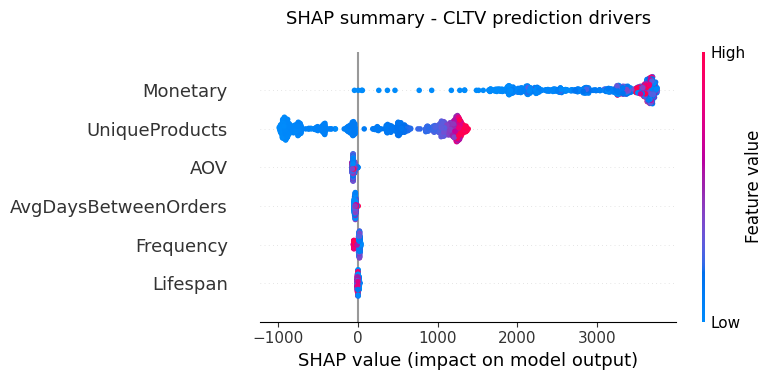

In [12]:
plt.figure(figsize=(10,6))
shap.summary_plot(cltv_shap_values,X_cltv_sample,show=False)

plt.title('SHAP summary - CLTV prediction drivers', fontsize=13,pad=20)
plt.tight_layout()
plt.savefig('../outputs/shap_cltv_beeswarm.png',dpi=100,bbox_inches='tight')
plt.show()

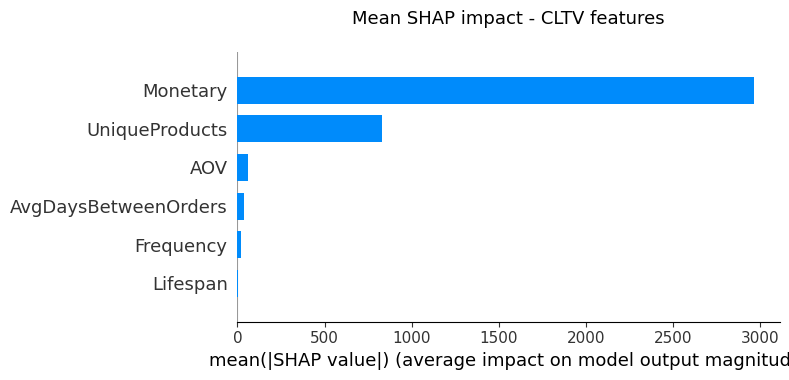

In [13]:
plt.figure(figsize=(10,6))
shap.summary_plot(cltv_shap_values,X_cltv_sample,plot_type='bar',show=False)

plt.title("Mean SHAP impact - CLTV features",fontsize=13,pad=20)
plt.tight_layout()
plt.savefig("../outputs/shap_cltv_bar.png",dpi=100,bbox_inches='tight')
plt.show()

In [14]:
sample_idx=X_cltv_sample.index
sample_cltv=df.loc[sample_idx,'CLTV']

high_idx_pos=sample_cltv.values.argmax()
low_idx_pos=sample_cltv.values.argmin()

print(f"High CLTV customer: {df.loc[sample_idx[high_idx_pos], 'CustomerID']}, "
      f"CLTV = £{sample_cltv.iloc[high_idx_pos]:,.2f}")
print(f"Low CLTV customer : {df.loc[sample_idx[low_idx_pos], 'CustomerID']}, "
      f"CLTV = £{sample_cltv.iloc[low_idx_pos]:,.2f}")

High CLTV customer: 14051, CLTV = £3,169.22
Low CLTV customer : 16446, CLTV = £1.45


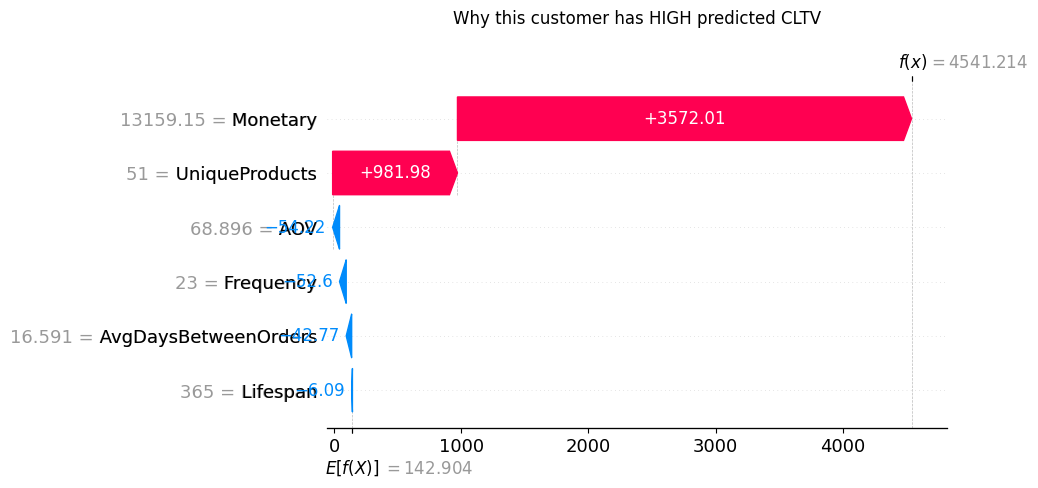

In [16]:
explanation_high=shap.Explanation(
    values=cltv_shap_values[high_idx_pos],
    base_values=cltv_explainer.expected_value,
    data=X_cltv_sample.iloc[high_idx_pos].values,
    feature_names=CLTV_FEATURES
)

plt.figure(figsize=(10,6))
shap.waterfall_plot(explanation_high,show=False)
plt.title('Why this customer has HIGH predicted CLTV', fontsize=12, pad=20)
plt.savefig('../outputs/shap_cltv_waterfall_high.png',dpi=100,bbox_inches='tight')
plt.show()

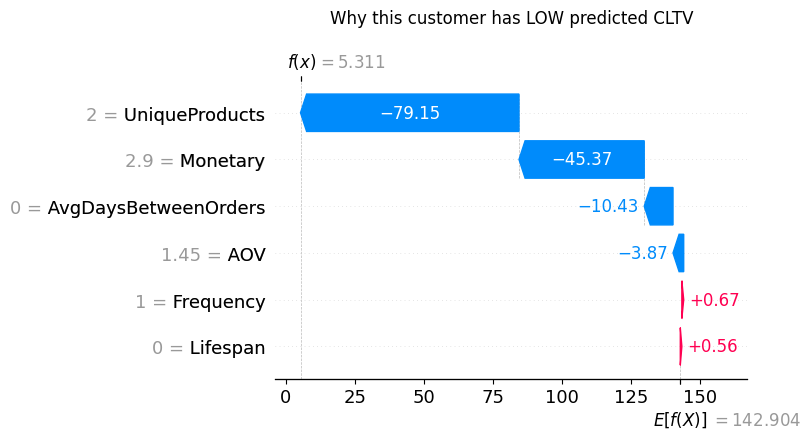

In [18]:
explanation_low = shap.Explanation(
    values=cltv_shap_values[low_idx_pos],
    base_values=cltv_explainer.expected_value,
    data=X_cltv_sample.iloc[low_idx_pos].values,
    feature_names=CLTV_FEATURES
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation_low, show=False)
plt.title('Why this customer has LOW predicted CLTV', fontsize=12, pad=20)
plt.tight_layout()
plt.savefig('../outputs/shap_cltv_waterfall_low.png', dpi=100, bbox_inches='tight')
plt.show()

In [21]:
X_churn_sample=X_churn.sample(n=SAMPLE_SIZE,random_state=42)

churn_explainer=shap.TreeExplainer(churn_model)
churn_shap_values=churn_explainer.shap_values(X_churn_sample)

if isinstance(churn_shap_values,list):
    churn_shap_values_class1=churn_shap_values[1]
    churn_expected_value=churn_explainer.expected_value[1]
    
elif churn_shap_values.ndim==3:
    churn_shap_values_class1=churn_shap_values[:,:,1]
    churn_expected_value=churn_explainer.expected_value[1]
    
else:
    churn_shap_values_class1=churn_shap_values
    churn_expected_value=churn_explainer.expected_value
    
print("Churn SHAP values shape:",churn_shap_values_class1.shape)
print("Expected value (base log_odds):",churn_expected_value)

Churn SHAP values shape: (1000, 6)
Expected value (base log_odds): -0.69803566


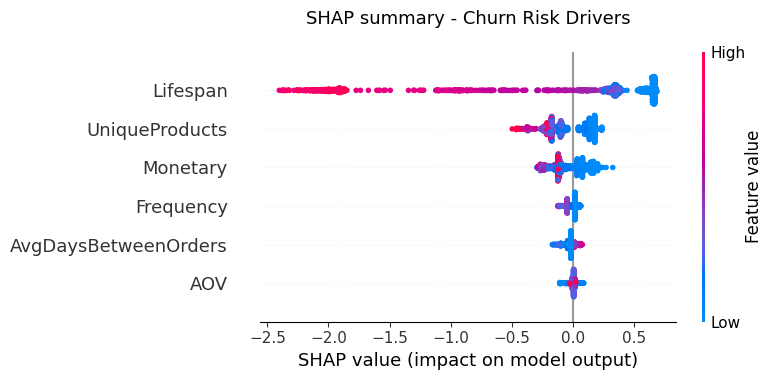

In [22]:
plt.figure(figsize=(10,6))
shap.summary_plot(churn_shap_values_class1,X_churn_sample,show=False)

plt.title('SHAP summary - Churn Risk Drivers', fontsize=13,pad=20)
plt.tight_layout()
plt.savefig('../outputs/shap_churn_beeswarm.png',dpi=100,bbox_inches='tight')
plt.show()

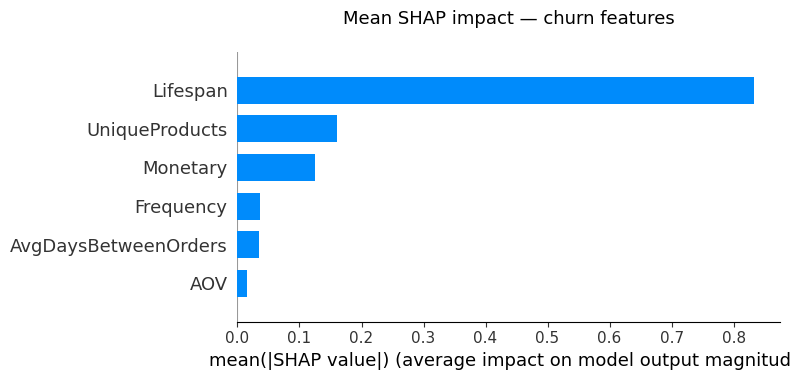

In [23]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    churn_shap_values_class1, X_churn_sample,
    plot_type='bar', show=False
)
plt.title('Mean SHAP impact — churn features', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig('../outputs/shap_churn_bar.png', dpi=100, bbox_inches='tight')
plt.show()

In [24]:
sample_idx_churn = X_churn_sample.index
sample_proba = df.loc[sample_idx_churn, 'Churn_Probability']

high_risk_pos = sample_proba.values.argmax()
low_risk_pos = sample_proba.values.argmin()

print(f"High risk customer: {df.loc[sample_idx_churn[high_risk_pos], 'CustomerID']}, "
      f"churn prob = {sample_proba.iloc[high_risk_pos]:.2f}")
print(f"Low risk customer : {df.loc[sample_idx_churn[low_risk_pos], 'CustomerID']}, "
      f"churn prob = {sample_proba.iloc[low_risk_pos]:.2f}")

High risk customer: 16765, churn prob = 0.61
Low risk customer : 13491, churn prob = 0.05


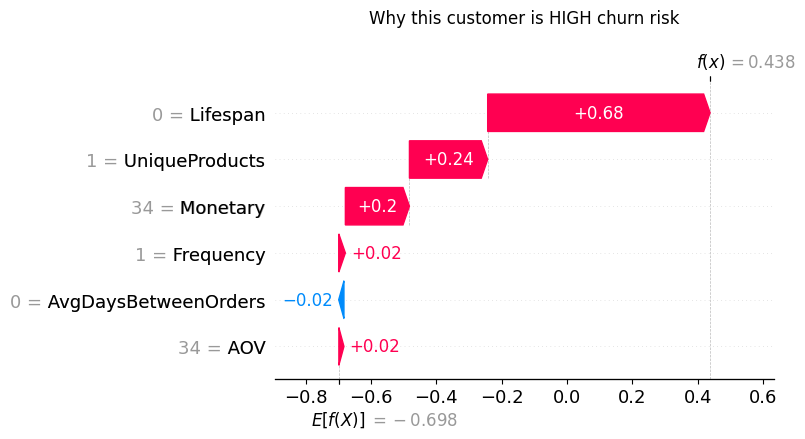

In [25]:
explanation_high_risk = shap.Explanation(
    values=churn_shap_values_class1[high_risk_pos],
    base_values=churn_expected_value,
    data=X_churn_sample.iloc[high_risk_pos].values,
    feature_names=CHURN_FEATURES
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation_high_risk, show=False)
plt.title('Why this customer is HIGH churn risk', fontsize=12, pad=20)
plt.tight_layout()
plt.savefig('../outputs/shap_churn_waterfall_high.png', dpi=100, bbox_inches='tight')
plt.show()

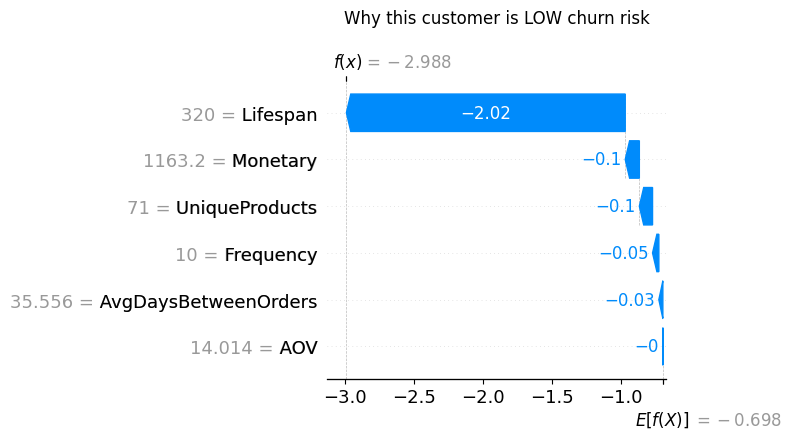

In [26]:
explanation_low_risk = shap.Explanation(
    values=churn_shap_values_class1[low_risk_pos],
    base_values=churn_expected_value,
    data=X_churn_sample.iloc[low_risk_pos].values,
    feature_names=CHURN_FEATURES
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation_low_risk, show=False)
plt.title('Why this customer is LOW churn risk', fontsize=12, pad=20)
plt.tight_layout()
plt.savefig('../outputs/shap_churn_waterfall_low.png', dpi=100, bbox_inches='tight')
plt.show()

Top CLTV Feature: Monetary


<Figure size 800x600 with 0 Axes>

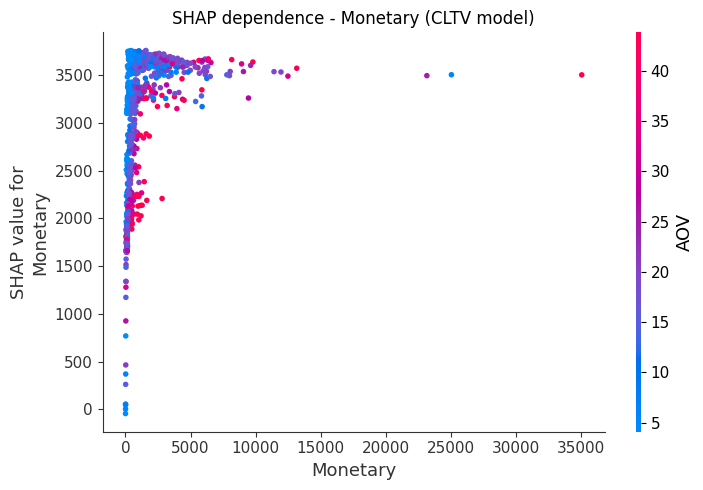

In [28]:
top_cltv_feature=CLTV_FEATURES[np.argmax(np.abs(cltv_shap_values).mean(axis=0))]
print("Top CLTV Feature:",top_cltv_feature)

plt.figure(figsize=(8,6))
shap.dependence_plot(top_cltv_feature,cltv_shap_values,X_cltv_sample, show=False)

plt.title(f"SHAP dependence - {top_cltv_feature} (CLTV model)")
plt.tight_layout()
plt.savefig("../outputs/shap_cltv_dependence.png",dpi=100,bbox_inches='tight')
plt.show()


Top Churn Feature: Lifespan


<Figure size 800x600 with 0 Axes>

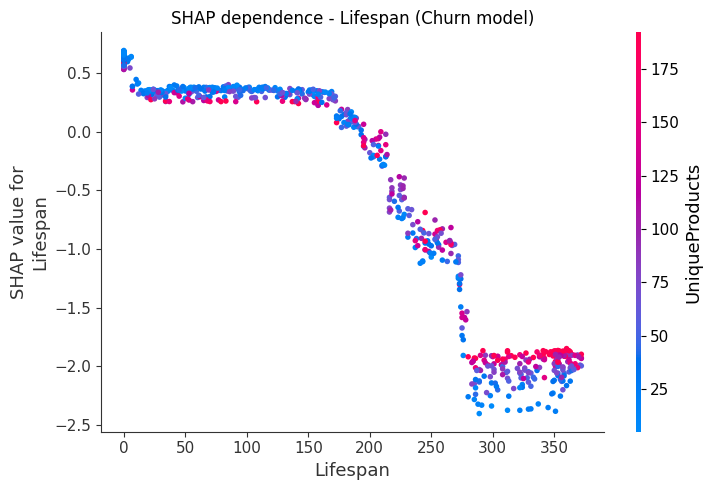

In [29]:
top_churn_feature=CHURN_FEATURES[np.argmax(np.abs(churn_shap_values_class1).mean(axis=0))]
print("Top Churn Feature:",top_churn_feature)

plt.figure(figsize=(8,6))
shap.dependence_plot(top_churn_feature,churn_shap_values_class1,X_churn_sample, show=False)

plt.title(f"SHAP dependence - {top_churn_feature} (Churn model)")
plt.tight_layout()
plt.savefig("../outputs/shap_churn_dependence.png",dpi=100,bbox_inches='tight')
plt.show()


In [30]:
import os
os.makedirs('../models', exist_ok=True)

# Save as .bz2 — compressed pickle, keeps file size manageable for deployment
with bz2.BZ2File('../models/cltv_explainer.bz2', 'wb') as f:
    pickle.dump(cltv_explainer, f)

with bz2.BZ2File('../models/churn_explainer.bz2', 'wb') as f:
    pickle.dump(churn_explainer, f)

print("Saved:")
print("  models/cltv_explainer.bz2")
print("  models/churn_explainer.bz2")

Saved:
  models/cltv_explainer.bz2
  models/churn_explainer.bz2


# SHAP Explainability — Key Findings

**CLTV model:**
- Monetary is the strongest driver of predicted 
  customer lifetime value, consistent with RFM theory
- UniqueProducts shows a positive relationship — customers with 
  higher product diversity tend to have higher predicted CLTV
- The waterfall plots show that for the highest-value customer, Monetary
  contributed +£3572 and UniqueProducts contributed +£982 to the prediction of £4,541 compared 
  to the baseline value of £143

**Churn model:**
- Lifespan is the strongest signal for predicting churn risk
- This makes business sense because customers with a longer relationship history have 
  established purchasing habits and stronger loyalty, whereas newly acquired customers 
  are far more likely to stop purchasing and churn
- The dependence plot shows churn risk increases sharply once customer lifespan drops 
  below 200 days, giving a concrete signal for early intervention

**Business implication:** these explanations let the retention team understand 
why a customer is flagged as high-value or high-risk, not just receive a 
black-box number — supporting targeted, justified interventions rather than 
blanket campaigns.